# Setting up

## Accessing Data

In [1]:
#This gets us into the right directory from home, in order to run the import python script from Mat

#sys = system (module), gives information and control over python interpreter/terminal itself
import sys
sys.path.append("/home/565/pv3484/aus_substation_electricity")

#% is a magic command, special shortcut command that lets you control/interact with notebook environment (ie. gives control of terminal without writing full python code)
%cd /home/565/pv3484/aus_substation_electricity

!pwd

/home/565/pv3484/aus_substation_electricity
/home/565/pv3484/aus_substation_electricity


In [2]:
#This section imports the substations that Mat put together

%run /home/565/pv3484/aus_substation_electricity/import_substation.py


processing nsw substations for ['ausgrid'] from None to None
ausgrid
following columns in demand are not in info index:
['MT_HU', 'SI_NO']
removing these columns from demand
number of substations in ausgrid substation info: 134
number of substations in ausgrid substation data: 132
following sites match selection criteria:
               energy_asset          Name  Area  Dwellings  Persons  Residential  Commercial  Industrial  Primary Production  Education  \
ID                                                                                                                                        
BLAKE         AG_BLAKEHURST    Blakehurst     7      10081    28521        0.850       0.005       0.021               0.000      0.022   
PUNCH          AG_PUNCHBOWL     Punchbowl     9      17514    50395        0.826       0.048       0.038               0.000      0.025   
MEADO         AG_MEADOWBANK    Meadowbank    15      22420    56948        0.825       0.023       0.015               0

## Adding lat/lon

In [3]:
from geopy.geocoders import Nominatim
import pandas as pd
import time

# Initialize geocoder
geolocator = Nominatim(user_agent="sydney_demand_mapper")

def get_coords(place):
    """Return (lat, lon) for a suburb name, or (None, None) if not found."""
    try:
        loc = geolocator.geocode(f"{place}, New South Wales, Australia")
        if loc:
            return loc.latitude, loc.longitude
    except Exception as e:
        print(f"Geocoding failed for {place}: {e}")
    return None, None

# Apply geocoding to the 'Name' column
latitudes, longitudes = [], []
for suburb in info['Name']:
    lat, lon = get_coords(suburb)
    latitudes.append(lat)
    longitudes.append(lon)
    time.sleep(1)  # polite pause to avoid hitting API limits

info['latitude'] = latitudes
info['longitude'] = longitudes

### Fixing Dee Why

In [4]:
missing = info[info["latitude"].isna() | info["longitude"].isna()]
missing["Name"].unique()
#Dee Why West doesn't exist as a suburb polygon, so will need to change the name to Dee Why

array(['Dee Why West'], dtype=object)

In [5]:
dee_why_west_lat = -33.73441
dee_why_west_lon = 151.28278
#Found the lat/lon information online

In [6]:
info.loc[info["Name"] == "Dee Why West", "latitude"] = dee_why_west_lat
info.loc[info["Name"] == "Dee Why West", "longitude"] = dee_why_west_lon
#inputting lat and lon from online into info

In [ ]:
info.head(20)

# Plotting
- Basic plots for results/data section in thesis
- Plotting raw demand for all days (weekends and weekdays) against temperature
- To show what we expect it to show (V or U shape - less so on weekends vs weekdays)
- Demand at peak times 3pm - 8pm
- Differences between seasons

In [21]:
sub = "BLAKE"   # or any other substation name

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure datetime index
demand.index = pd.to_datetime(demand.index)
obs.index = pd.to_datetime(obs.index)

# Extract date + hour
demand["date"] = demand.index.date
demand["hour"] = demand.index.hour
obs["date"] = obs.index.date

# Filter to 15:00–20:00
df_window = demand[(demand["hour"] >= 15) & (demand["hour"] < 20)]

# Identify substation columns
substations = [c for c in demand.columns if c not in ["date", "hour"]]

# Daily mean demand for each substation
daily_demand = (
    df_window.groupby("date")[substations]
    .mean()
    .reset_index()
)

# -----------------------------
# Detect temperature column
# -----------------------------
temp_cols = [c for c in obs.columns 
             if ("t2" in c.lower()) or ("temp" in c.lower())]

if len(temp_cols) == 0:
    raise ValueError("No temperature-like column found in obs dataframe.")

temp_col = temp_cols[0]
print("Using temperature column:", temp_col)

#hour window matched temperature
obs["hour"] = obs.index.hour

temp_window = obs[(obs["hour"] >= 15) & (obs["hour"] < 20)]

temp_daily = (
    temp_window.groupby("date")[temp_col]
    .mean()
    .rename("temp_mean")
    .reset_index()
)


# Daily mean temperature
temp_daily = (
    obs.groupby("date")[temp_col]
    .mean()
    .rename("temp_mean")
    .reset_index()
)

# Merge demand + temperature and classify weekdays/weekends
merged = daily_demand.merge(temp_daily, on="date", how="left")
merged["date"] = pd.to_datetime(merged["date"])
merged["is_weekend"] = merged["date"].dt.weekday >= 5

full_name = info.loc[sub, "Name"]
plt.figure(figsize=(8,5))

wk = merged[~merged["is_weekend"]]
we = merged[merged["is_weekend"]]

plt.scatter(wk["temp_mean"], wk[sub],
            color="lightgrey", s=15, label="Weekday")

plt.scatter(we["temp_mean"], we[sub],
            color="lightblue", s=15, label="Weekend")

plt.title(f"{full_name} — Mean Demand (3–8 pm) vs Temperature")
plt.xlabel("Daily Mean Temperature (°C)")
plt.ylabel("Mean Demand from 3pm to 8 pm (MW/h)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.close()


Using temperature column: t2m


In [11]:
print(obs.columns.tolist())


['t2m', 't2m_30max', 't2m_30min', 't2m_bin', 'date']


## Plotting above but in 3 year blocks

In [63]:
merged["year"] = merged["date"].dt.year

# Define 3-year blocks
def block_label(y):
    start = (y - 2004) // 3 * 3 + 2004
    end = start + 2
    return f"{start}-{end}"

merged["block"] = merged["year"].apply(block_label)

blocks = merged["block"].unique()
blocks = sorted(blocks)   # ensure chronological order

import math
blocks = sorted(merged["block"].unique())

n = len(blocks)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows), sharex=True, sharey=True)
axes = axes.flatten()

for ax, blk in zip(axes, blocks):
    data = merged[merged["block"] == blk]

    wk = data[~data["is_weekend"]]
    we = data[data["is_weekend"]]

    ax.scatter(wk["temp_mean"], wk[sub], s=12, color="lightgrey", label="Weekday")
    ax.scatter(we["temp_mean"], we[sub], s=12, color="lightblue", label="Weekend")

    ax.set_title(blk)
    ax.grid(alpha=0.3)

# turn off unused axes
for ax in axes[len(blocks):]:
    ax.axis("off")

full_name = info.loc[sub, "Name"]
fig.suptitle(f"{full_name} — Demand vs Temperature (3‑year blocks)", fontsize=16)
fig.supxlabel("Mean Temperature (3–8 pm)")
fig.supylabel("Mean Demand (3–8 pm)")

# --- Add legend here ---
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([], [], marker='o', color='lightgrey', linestyle='', markersize=8, label='Weekday'),
    Line2D([], [], marker='o', color='lightblue', linestyle='', markersize=8, label='Weekend')
]
fig.legend(handles=legend_elements, loc='center right', bbox_to_anchor=(0.8, 0.44), title = 'Legend')

plt.tight_layout()
plt.close()



## Plotting raw demand vs temperature for all days (weekends vs weekdays) for all locations and saving

In [64]:
import os
from matplotlib.lines import Line2D

save_dir = "/home/565/pv3484/aus_substation_electricity/figures/demand_v_temp_15_20pm"
os.makedirs(save_dir, exist_ok=True)

for sub in substations:

    # Full name for title
    full_name = info.loc[sub, "Name"] if sub in info.index else sub

    # Safe filename
    safe_title = full_name.replace(" ", "_").replace("/", "-")
    outfile = os.path.join(save_dir, f"{safe_title}.png")

    # Extract weekday/weekend
    wk = merged[~merged["is_weekend"]]
    we = merged[merged["is_weekend"]]

    # Create figure
    fig, ax = plt.subplots(figsize=(7,5))

    ax.scatter(wk["temp_mean"], wk[sub], s=15, color="lightgrey")
    ax.scatter(we["temp_mean"], we[sub], s=15, color="lightblue")

    ax.set_title(f"{full_name} — Demand vs Temperature (3–8 pm)")
    ax.set_xlabel("Mean Temperature (3–8 pm)")
    ax.set_ylabel("Mean Demand (3–8 pm)")
    ax.grid(alpha=0.3)

    # Legend for dot colours
    legend_elements = [
        Line2D([], [], marker='o', color='lightgrey', linestyle='', markersize=8, label='Weekday'),
        Line2D([], [], marker='o', color='lightblue', linestyle='', markersize=8, label='Weekend')
    ]
    ax.legend(handles=legend_elements, title="Dot colours")

    fig.tight_layout()
    fig.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.close(fig)


## Plotting a 2x2 seasonal grid

In [65]:
def get_season(dt):
    m = dt.month
    if m in [12, 1, 2]:
        return "Summer"
    elif m in [3, 4, 5]:
        return "Autumn"
    elif m in [6, 7, 8]:
        return "Winter"
    else:
        return "Spring"

merged["season"] = merged["date"].apply(get_season)


In [70]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_seasons_for_substation(sub):
    full_name = info.loc[sub, "Name"] if sub in info.index else sub
    seasons = ["Summer", "Autumn", "Winter", "Spring"]

    fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
    
    for ax, season in zip(axes, seasons):
        data = merged[merged["season"] == season]

        wk = data[~data["is_weekend"]]
        we = data[data["is_weekend"]]

        ax.scatter(wk["temp_mean"], wk[sub], s=12, color="lightgrey")
        ax.scatter(we["temp_mean"], we[sub], s=12, color="lightblue")

        ax.set_title(season)
        ax.grid(alpha=0.3)

    fig.suptitle(f"{full_name} — Demand vs Temperature(Daily Mean, 3-8pm) by Season", fontsize=16)
    fig.supxlabel("Mean Temperature (3–8 pm)")
    fig.supylabel("Mean Demand (3–8 pm)")

    legend_elements = [
        Line2D([], [], marker='o', color='lightgrey', linestyle='', markersize=8, label='Weekday'),
        Line2D([], [], marker='o', color='lightblue', linestyle='', markersize=8, label='Weekend')
    ]
    fig.legend(handles=legend_elements, loc='upper right')

    plt.tight_layout()
    plt.show()


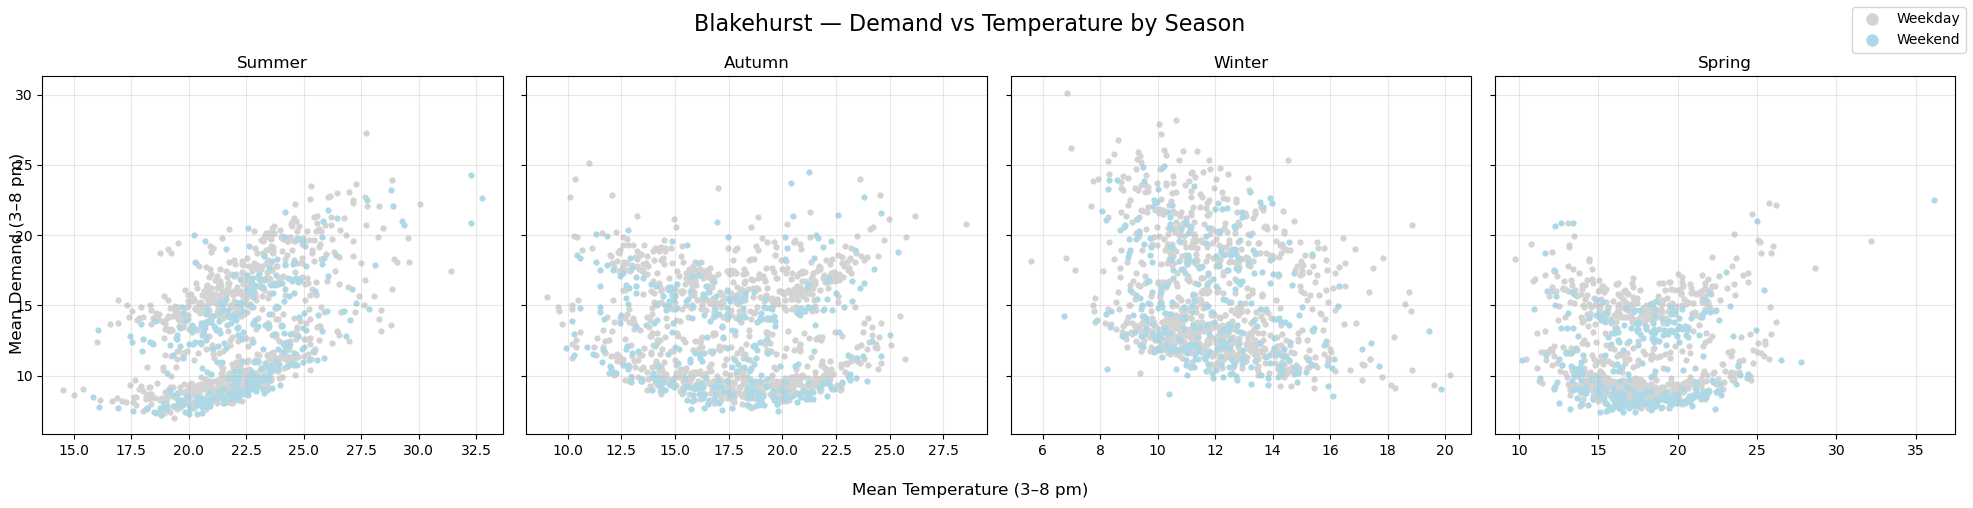

In [71]:
plot_seasons_for_substation("BLAKE")


### Saving above

In [78]:
import os
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

save_dir = "/home/565/pv3484/aus_substation_electricity/figures/raw_demand_v_temp/seasonal"
os.makedirs(save_dir, exist_ok=True)

seasons = ["Summer", "Autumn", "Winter", "Spring"]

for sub in substations:

    # Full name for title
    full_name = info.loc[sub, "Name"] if sub in info.index else sub
    suptitle = f"{full_name} - Demand vs Temperature(Daily Mean, 3-8pm) by Season"

    # Safe filename
    safe_name = suptitle.replace(" ", "_").replace("/", "-")
    outfile = os.path.join(save_dir, f"{safe_name}.png")

    # Create 1×4 grid
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

    for ax, season in zip(axes, seasons):
        data = merged[merged["season"] == season]

        wk = data[~data["is_weekend"]]
        we = data[data["is_weekend"]]

        ax.scatter(wk["temp_mean"], wk[sub], s=12, color="lightgrey")
        ax.scatter(we["temp_mean"], we[sub], s=12, color="lightblue")

        ax.set_title(season)
        ax.grid(alpha=0.3)

    fig.suptitle(suptitle, fontsize=16)
    fig.supxlabel("Mean Temperature (3–8 pm)")
    fig.supylabel("Mean Demand (3–8 pm)")

    # Legend
    legend_elements = [
        Line2D([], [], marker='o', color='lightgrey', linestyle='', markersize=8, label='Weekday'),
        Line2D([], [], marker='o', color='lightblue', linestyle='', markersize=8, label='Weekend')
    ]
    fig.legend(handles=legend_elements, loc='upper right')

    plt.tight_layout()
    fig.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.close(fig)
